<a href="https://colab.research.google.com/github/sj-workbench/years_of_learnings/blob/main/percentile_winsorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# In this dataset i have worked on Percentile Winrorization detecting and removing the outlier.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("/content/SOCR-HeightWeight.csv")
df

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971
...,...,...,...
24995,24996,69.50215,118.0312
24996,24997,64.54826,120.1932
24997,24998,64.69855,118.2655
24998,24999,67.52918,132.2682


In [4]:
df['Height(Inches)'].describe()

,Height(Inches)
count,25000.000000
mean,67.993114
std,1.901679
min,60.278360
25%,66.704397
50%,67.995700
75%,69.272958
max,75.152800


In [5]:
import seaborn as sns

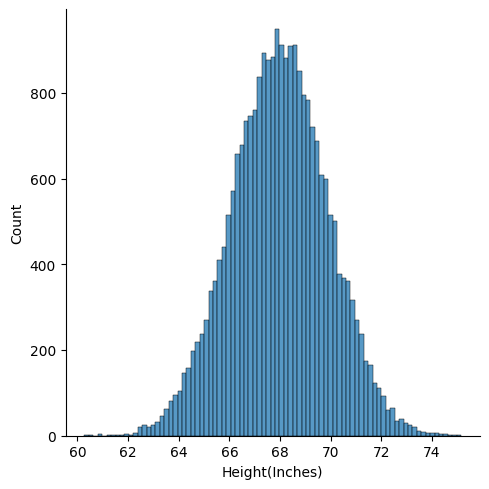

In [7]:
sns.displot(df['Height(Inches)'])

<Axes: ylabel='Height(Inches)'>

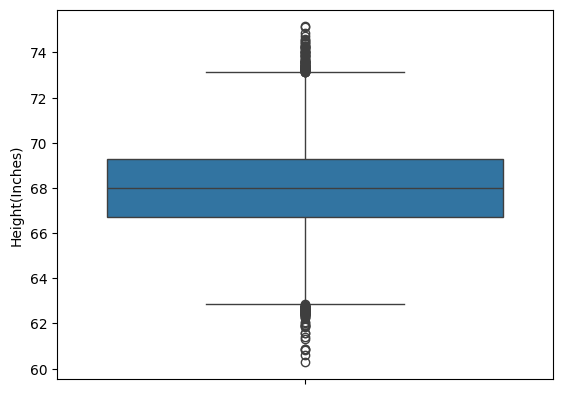

In [8]:
sns.boxplot(df['Height(Inches)'])

In [10]:
upper_limit = df['Height(Inches)'].quantile(0.99)
upper_limit

np.float64(72.37221499999998)

In [12]:
lower_limit = df['Height(Inches)'].quantile(0.01)
lower_limit

np.float64(63.5986493)

In [18]:
# Trimming
new_df = df[(df['Height(Inches)']<=72.3) & (df['Height(Inches)']>=63.5)]
new_df

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971
...,...,...,...
24995,24996,69.50215,118.0312
24996,24997,64.54826,120.1932
24997,24998,64.69855,118.2655
24998,24999,67.52918,132.2682


In [19]:
new_df['Height(Inches)'].describe()

,Height(Inches)
count,24494.000000
mean,67.980102
std,1.779046
min,63.500440
25%,66.728705
50%,67.989270
75%,69.236475
max,72.297830


In [20]:
df['Height(Inches)'].describe()

,Height(Inches)
count,25000.000000
mean,67.993114
std,1.901679
min,60.278360
25%,66.704397
50%,67.995700
75%,69.272958
max,75.152800


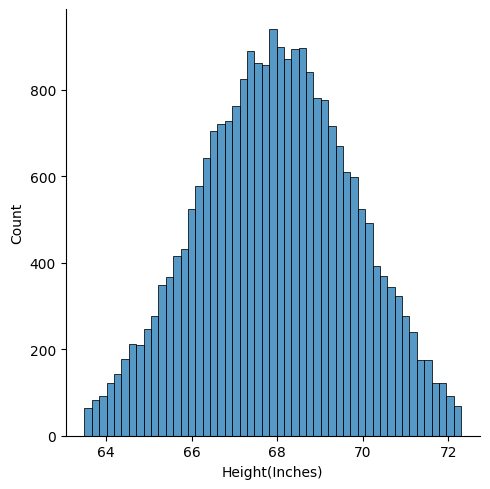

In [22]:
sns.displot(new_df['Height(Inches)'])

<Axes: ylabel='Height(Inches)'>

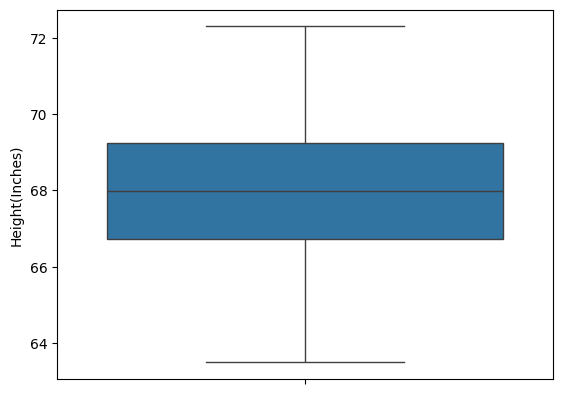

In [23]:
sns.boxplot(new_df['Height(Inches)'])

In [27]:
# Cappiing = Winzorization
df['Height(Inches)'] = np.where(df['Height(Inches)']>=upper_limit,upper_limit,
         np.where(df['Height(Inches)']<=lower_limit,lower_limit,df['Height(Inches)']))

In [28]:
df['Height(Inches)'].describe()

,Height(Inches)
count,25000.000000
mean,67.992508
std,1.868011
min,63.598649
25%,66.704397
50%,67.995700
75%,69.272958
max,72.372215


<Axes: ylabel='Height(Inches)'>

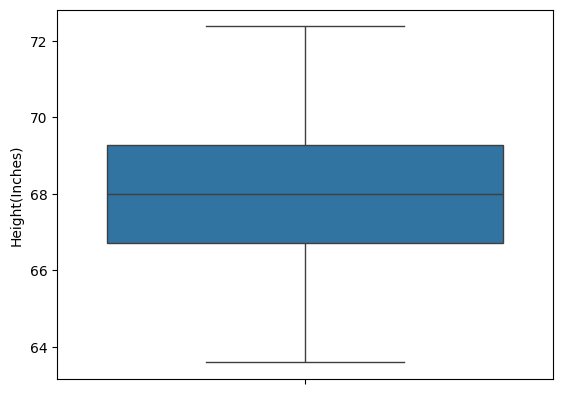

In [29]:
sns.boxplot(df['Height(Inches)'])